# **Algunas visualizaciones de attention**

En este notebook exploraremos algunas visualizaciones del modelo de attention a través de [BERT](https://huggingface.co/docs/transformers/model_doc/bert).

BERT es un modelo transformer **encoder-only** ,esto significa que solo usa la mitad "de entender" de la arquitectura completa (sin decoder, sin
generación de texto palabra por palabra).

Fue entrenado por Google, ya con sus pesos ajustados
(pre-entrenado) sobre grandes cantidades de texto

No lo vamos a entrenar nosotros, solo vamos a usar un
modelo que ya aprendió a calcular attention de forma útil.

`bert-base-uncased`:
- **base** = el tamaño más chico de BERT (12 capas,
  12 cabezas por capa)
- **uncased** = no distingue mayúsculas de minúsculas
  ("The" y "the" se tratan igual)

La primera vez que corran esta celda, va a descargar
el modelo desde [HuggingFace](https://huggingface.co/) (una plataforma que aloja modelos pre-entrenados), por lo que puede tardar un poco, es normal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
!pip install bertviz -q #se corre solo una vez!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 4.2 MB/s eta 0:00:00


In [4]:
#se corre solo una vez para cargar el modelo
from bertviz import head_view
from transformers import BertTokenizer, BertModel

model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("Modelo cargado, listo para usar")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Modelo cargado, listo para usar


# 1. Multi-head attention

El transformer no hace attention una sola vez, la repite en varias capas apiladas

- Layer = en cuál de esas capas estás mirando
(BERT-base tiene 12 capas, apiladas una sobre otra)

- Head = dentro de esa capa, cuál cabeza de multi-head
attention estás mirando
(BERT-base tiene 12 cabezas, en paralelo, dentro de cada capa)

12 capas × 12 cabezas = 144 "vistas" de attention distintas
en todo el modelo

La cabeza roja en la Layer 3 no tiene relación directa
con la cabeza roja en la Layer 8, son patrones independientes

In [33]:
frase1 = "The trophy didn't fit in the suitcase because it was too big"
frase2 = "The city council refused the demonstrators a permit because they feared violence"
frase3 = "The animal didn't cross the street because it was too tired"
frase4 = "The baby was playing with the glass and he broke it"
frase5 = "The error in the code is between the computer and the chair"

inputs = tokenizer.encode(frase4, return_tensors='pt')
outputs = model(inputs)
attention = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs[0])

head_view(attention, tokens)

<IPython.core.display.Javascript object>

### **Actividad**

1. Escribe tu propia oración con una palabra ambigua
   (que podría referirse a más de una cosa). Reemplaza
   el texto en "oracion" en la celda de arriba

2. Antes de correr, predice a mano a qué palabra debería
   atender esa palabra ambigua
   - he debiera atender a baby, e it a glass

3. Corre la celda. Haz clic en la palabra ambigua en el
   visualizador para ver las líneas de atención

4. Compara: ¿acertaste? ¿Qué cabeza (color) capturó la
   relación que esperabas?
   No se dió la relación con la fuerza que esperaba

# 2. Self-attention con pesos reales

Ahora usamos las matrices W_Q, W_K, W_V que BERT realmente
aprendió durante su entrenamiego — el mismo cálculo que ya
programaron a mano, pero con pesos entrenados en vez de
aleatorios.

Prueben cambiar `num_capa` (0 a 11) y comparen los patrones:

- Capas tempranas (0-1): attention más local, o colapsando
  hacia tokens especiales como [CLS]
- Capas intermedias/profundas: patrones distintos, pero
  cuidado: este código combina las 12 cabezas en un solo
  promedio, así que relaciones específicas pueden diluirse acá

Si el resultado no muestra una relación "clara" como en
BertViz, no es un error: significa que esa relación vivía
en UNA cabeza específica, no en el promedio de las 12.


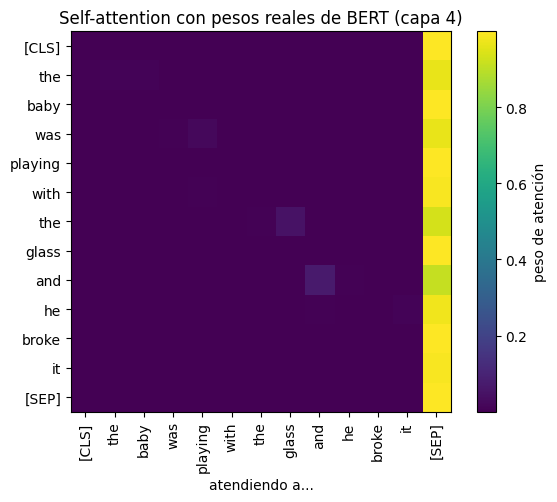

In [50]:
# Elegir qué capa mirar (0 a 11)
num_capa = 4

inputs = tokenizer(frase4, return_tensors='pt') #tokenizador de la frasw
outputs = model(**inputs, output_hidden_states=True) #guarda el resultado de cada capa

# hidden_states[0] = embeddings originales (entrada a la capa 0)
# hidden_states[N] = salida de la capa N-1 (entrada a la capa N)
entrada_a_esta_capa = outputs.hidden_states[num_capa].detach().numpy()[0]
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

capa = model.encoder.layer[num_capa].attention.self
#matrices de pesos reales ya entrenados de BERT
W_Q_real = capa.query.weight.detach().numpy()
W_K_real = capa.key.weight.detach().numpy()
W_V_real = capa.value.weight.detach().numpy()

# @ en numpy es el operador de multiplicación de matrices
Q = entrada_a_esta_capa @ W_Q_real.T
K = entrada_a_esta_capa @ W_K_real.T
V = entrada_a_esta_capa @ W_V_real.T

d = Q.shape[1]
#producto punto escalado de attention
scores = (Q @ K.T) / np.sqrt(d)
exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True)) #softmax
pesos_atencion = exp_scores / exp_scores.sum(axis=1, keepdims=True)

#visualización
plt.figure(figsize=(6,5))
plt.imshow(pesos_atencion, cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("atendiendo a...")
plt.colorbar(label="peso de atención")
plt.title(f"Self-attention con pesos reales de BERT (capa {num_capa})")
plt.tight_layout()
plt.show()

### **Observe y responda**

- ¿Hacia qué palabra(s) se concentra la mayor parte de la
  atención en esta capa?  
  No parece haber especial atenció hacia alguna palabra en las capas
- ¿Es un patrón interpretable (relación de significado) o
  parece attention "colapsando" hacia puntuación/tokens
  especiales?  
  La attention tiende a colapsar hacia los tokens especiales
- Compare con el resultado de otra capa: ¿qué cambió?  
  En la segunda capa se puede ver que esta la atención secuenciada en la frase. No se dan casos esperables de atención baby-he, o glass-it.


# 3. Clasificador de sentimiento

`pipeline("sentiment-analysis")` descarga un modelo ya
entrenado específicamente para una tarea: decidir si un
texto es POSITIVO o NEGATIVO.

Por dentro sigue siendo un transformer (parecido a BERT), con el mismo mecanismo de attention, pero fue
afinado (fine-tuning) con miles de ejemplos de texto
etiquetados como positivo/negativo, hasta aprender a
distinguir el tono de un texto.

El resultado incluye un "label" (POSITIVE o NEGATIVE) y
un "score" (qué tan seguro está el modelo de esa clasificación).

En este caso, usaremos DistilBERT, que está basado en BERT pero es una versión más comprimida.

- BERT-base: 12 capas, 768 dimensiones, ~110 millones de parámetros

- DistilBERT: 6 capas (la mitad), misma dimensión (768),
                 ~66 millones de parámetros
                 → ~40% más chico, ~60% más rápido,
                 conservando ~97% del rendimiento de BERT
                 en varias tareas

In [60]:
from transformers import pipeline

clasificador = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english") #modelo fine-tuned para análisis de sentimiento

frase="Oh wonderful, it started raining just when I stepped outside without an umbrella"

resultado = clasificador(frase)
print(resultado)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9995492100715637}]


### **Actividad**

1. Cambie "frase" por algo suyo; pueden probar una
   frase claramente positiva, una negativa, y una ambigua
   o irónica (ej. "great, another Monday")

2. Observe el "score" (la probabilidad), no solo el
   label. ¿Qué tan seguro está el modelo?  
   En general presenta seguridad con la presencia de ciertas palabras asociadas a cosas negativas o positivas. Cuando hay frases ambiguas o neutras, cae en algún label pero con baja probabilidad (< 60%)

3. Pruebe una oración con sarcasmo o doble sentido.
   ¿El modelo lo detecta, o falla?  
   Falla. Puede ser por el uso de palabras asociadas con algo bueno, en este caso wonderful

###

# 4. Extrayendo embeddings de una oración

`pipeline("feature-extraction")` toma un texto y devuelve
un vector numérico para cada token de esa oración, que es la
representación final que BERT genera después de procesar
toda la oración a través de sus 12 capas.

Estos vectores capturan tanto el significado de cada palabra
como el contexto de las palabras que la rodean. Se usan,
por ejemplo, para comparar qué tan similares son dos textos,
o como entrada para otro modelo que necesite trabajar con
texto ya convertido a números.

El resultado es una matriz: una fila por token, y cada fila
tiene 768 números (el tamaño del vector que usa BERT-base).



In [61]:
extractor = pipeline("feature-extraction", model="bert-base-uncased")

embedding = extractor("The animal didn't cross the street because it was too tired")
print("Forma del embedding:", len(embedding[0]), "(filas) x", len(embedding[0][0]), "(columnas)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Forma del embedding: 15 (filas) x 768 (columnas)


## Qué significa la forma del embedding

**X (filas):** es la cantidad de tokens en que quedó
dividida la oración. No es necesariamente la cantidad de
palabras, BERT tokeniza así:

- Agrega [CLS] al principio y [SEP] al final (2 tokens extra)
- Puede partir una palabra en varios pedazos si no la
  reconoce completa en su vocabulario (ej. "didn't" puede
  quedar dividido en "didn" + "'" + "t")

Por eso el conteo final de tokens casi nunca coincide con
contar palabras separadas por espacios.

**768 (columnas):** es el tamaño del vector de embedding
que BERT-base usa para representar cada token. Es un
número fijo, decidido por quienes diseñaron y entrenaron
este modelo específico, no es un valor universal, otros
modelos usan otros tamaños (BERT-large usa 1024, por
ejemplo).

**Entonces la matriz completa (X x 768)** es: por cada uno
de los 11 tokens de la oración, un vector de 768 números
que lo representa

# 5. Embeddings similares

Este código extrae el vector (embedding) que BERT genera
para la palabra "bank" en dos oraciones distintas:

- "I deposited money at the bank" (banco financiero)
- "We sat by the river bank" (orilla de un río)

`obtener_embedding_palabra` tokeniza la oración, la pasa
por el modelo, encuentra la posición exacta de la palabra
"bank" entre los tokens, y devuelve su vector final.

Después se calcula la similaridad coseno entre ambos
vectores, el resultado es un número entre 0 y 1 que mide qué tan parecidos
son. 1 significa idénticos, 0 significa sin relación.

Si el resultado sale bajo, significa que BERT generó
representaciones distintas para la misma palabra, según
el contexto de cada oración.

In [71]:
def obtener_embedding_palabra(frase, palabra_objetivo):
    inputs = tokenizer(frase, return_tensors='pt')
    outputs = model(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    idx = tokens.index(palabra_objetivo)
    return outputs.last_hidden_state[0, idx].detach().numpy()

frase1 = "They lead the project to success"
frase2 = "This water pipe is made of lead"
palabraObjetivo = "lead"

emb1 = obtener_embedding_palabra(frase1, palabraObjetivo)
emb2 = obtener_embedding_palabra(frase2, palabraObjetivo)

frase3 = "She hit her head"
frase4 = "His head is bald"
palabraObjetivo2 = "head"

emb3 = obtener_embedding_palabra(frase3, palabraObjetivo2)
emb4 = obtener_embedding_palabra(frase4, palabraObjetivo2)
# Similaridad coseno: 1 = idénticos, 0 = sin relación
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

similaridad = cos_sim(emb1, emb2)
similaridad2 = cos_sim(emb3, emb4)
print(f"Similaridad entre 'lead' (liderar) y lead (plomo): {similaridad:.3f}")
print(f"Similaridad entre 'head' (cabeza) y head (cabeza): {similaridad2:.3f}")

Similaridad entre 'lead' (liderar) y lead (plomo): 0.299
Similaridad entre 'head' (cabeza) y head (cabeza): 0.521


### **Actividad**

1. Elija una palabra en inglés con dos significados
   distintos (ej. "bat" — animal / objeto deportivo,
   "spring" — estación / resorte, "match" — fósforo / partido)

2. Escriba dos oraciones donde esa palabra tenga cada
   significado

3. Reemplace `frase1`, `frase2` y `palabra_objetivo` en
   el código con las suyas, y corra la celda

4. ¿qué tan alta o baja salió la
   similaridad? Tiene sentido?

5. Pruebe también con la **misma** palabra usada dos veces
   con el **mismo** significado, en oraciones distintas
   (ej. "bank" financiero en dos contextos distintos).
   ¿La similaridad sale más alta que en el caso ambiguo?

   En este caso se usó lead como liderar y como plomo. La similaridad fue baja, de un 0.299 lo cual tiene sentido.

   En el segundo caso curiosamente se obtuvo una similaridad mayor, mas no con mucha certeza.




# 6. Context size

Este código muestra el límite real de tokens que BERT puede
procesar de una vez (`tokenizer.model_max_length`).

Después genera un texto artificialmente largo (la misma
oración repetida 1000 veces) y cuenta cuántos tokens resultan
al tokenizarlo.

Si esa cantidad supera el límite del modelo, lo va a indicar
explícitamente. Esto muestra de forma concreta algo que ya
vimos en la teoría: el contexto no es ilimitado, y un texto
real puede superarlo fácilmente.

In [72]:
# Ver el context size real del modelo que ya tienen cargado
print("Context size máximo de BERT:", tokenizer.model_max_length)

# Generar un texto artificialmente largo y ver qué pasa
texto_largo = "El gato come pescado. " * 1000  # se repite 1000 veces

tokens = tokenizer.encode(texto_largo)
print("Cantidad de tokens generados:", len(tokens))

if len(tokens) > tokenizer.model_max_length:
    print("¡Este texto EXCEDE el límite de contexto del modelo!")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8002 > 512). Running this sequence through the model will result in indexing errors


Context size máximo de BERT: 512
Cantidad de tokens generados: 8002
¡Este texto EXCEDE el límite de contexto del modelo!


# **Para las siguientes actividades, use el LLM de su preferencia (ChatGPT, Claude, Gemini, etc)**

## **Actividad: poniendo a prueba el context size**

1. Al empezar una conversación nueva, dile al modelo un
   dato inventado y específico, por ejemplo:
   "Mi número de la suerte es 4173. Recuérdalo."

2. Pégale un texto largo de relleno (puede ser un capítulo
   de Wikipedia, un paper, cualquier texto de varios miles
   de palabras) y pídele que lo resuma.

3. Sigue conversando sobre OTROS temas durante varios
   mensajes más (5-10 intercambios), sin mencionar el
   número de la suerte.

4. Al final, pregúntale: "¿cuál era mi número de la suerte?"

5. ¿lo recordó? ¿Lo recordó mal? Si la conversación
se hizo muy larga, ¿en qué momento empezó a fallar?

Le comenté sobre el nombre de mi gato, y le comencé a llenar de información. Comencé por un artículo de Wikipedia, y luego le comencé a pedir cosas varias tales como recetas, direcciones, meteorología, etc. Luego, 2 artículos de Wikipedia más. Llegando a 10 mensajes en total, entre estos, 3 artículos de Wikipedia, le pregunté de nuevo el nombre de mi gato y no supo responder.

**Nota**: los modelos actuales tienen ventanas de contexto
bastante grandes, así que es posible que el modelo SÍ
recuerde el número incluso con texto de relleno largo.
Si eso pasa, pruebe agregando más texto
de relleno, o una conversación más larga, para ver si en
algún punto empieza a fallar.

## Actividad: probando los límites en la práctica

1. Haz la misma pregunta con un prompt vago y uno claro.
   Compara las respuestas.

2. Pide un dato muy específico que dudas que el modelo
   pueda saber con certeza (un DOI, una fecha exacta, una
   cita textual). ¿Suena igual de seguro que cuando responde
   algo que sí sabe bien?

3. Anota: ¿en qué casos confiarías en la respuesta sin
   verificar, y en cuáles no?

Modelo usado: Gemini 3.6 Flash  
   **Prompt vago**: Dame una receta de café.  

   R:¡A que no hay nada mejor que un buen café para reanimar el día! Aquí tienes una receta para preparar un **Café Dalgona** (o café batido), que es superfácil de hacer, queda con una textura cremosa increíble y parece de cafetería de especialidad.

---

## ☕ Café Dalgona Cremoso

### 🛒 Ingredientes

* **2 cucharadas** de café soluble (instantáneo).
* **2 cucharadas** de azúcar (blanca o morena).
* **2 cucharadas** de agua muy caliente.
* **1 taza** de leche (entera, descremada o vegetal como almendra/avena).
* **Hielo** al gusto.

---

### 🥣 Paso a Paso

1. **Mezclar la base:** En un tazón pequeño, junta el café instantáneo, el azúcar y el agua caliente.
2. **Batir con ganas:**
* *Si usas batidor eléctrico:* Bate a velocidad media-alta por unos **2 a 3 minutos**.
* *Si usas batidor manual (globo):* Bate energicamente durante **5 a 8 minutos**.
* *El objetivo:* Buscarás una espuma firme, brillante y de color caramelo claro (tipo merengue).


3. **Servir:** En un vaso alto, coloca los cubos de hielo y vierte la leche fría dejando unos centímetros libres arriba.
4. **El toque final:** Agrega la crema de café sobre la leche con la ayuda de una cuchara.

---

> 💡 **Tip Pro:** Antes de tomarlo, mézclalo bien con un sorbete o cuchara para que la crema se integre con la leche helada. Si quieres ponerte gourmet, espolvorea un poco de cacao en polvo o canela por encima.

¿Te tinca probar esta versión fría o estabas buscando más bien un método tradicional de extracción (cafetera italiana, prensa francesa, etc.)?  

---

**Prompt detallado**: Dame una receta de café para una cafetera V60. Tengo un grano de Bolivia de la región de Caranaví. Presenta notas de Manzana Cocida, canela y miel de ulmo, con altitud de 1550 msnm, y es de varietal catuai rojo, typica, mondo novo, proceso lavado. Acidez y dulzor 3/4, cuerpo y amargor 2/4. Me interesa extraer la dulzura del café, principalmente apuntar a las notas de manzana cocida. Considera que no tengo un equipo con control de la temperatura del agua, pero si puedo medir el gramaje y el tiempo de extraído. Apunta a una extracción final de 300ml o similar.

R: Tienes entre manos un café boliviano espectacular. Al ser un café de proceso lavado, de altura (1550 msnm) y con ese perfil tan marcado por la manzana cocida, la canela y la miel de ulmo, la clave para **maximizar la dulzura y resaltar esa nota a compota de manzana** está en:

1. **Garantizar una alta extracción inicial** (las notas dulces y ácidas frutas como la manzana se extraen temprano).
2. **Controlar la temperatura "a ojo"** para no amargar la taza (ya que no tienes hervidor con termostato).

Aquí tienes una receta diseñada a la medida para tu V60:

---

## ☕ Receta V60: "Manzana Cocida & Miel"

### **Especificaciones**

* **Dosis de café:** 18 g
* **Agua total:** 300 ml (Ratio 1:16.6)
* **Rendimiento final:** ~260 - 270 ml servidos en taza.
* **Molienda:** Media-fina (similar a sal de mesa fina).
* **Tiempo total de extracción:** 2:30 a 3:00 minutos.

---

### **Preparación de la Temperatura (Sin Termostato)**

1. Hirve tu agua por completo.
2. Déjala reposar con la tapa abierta durante **1 minuto a 1:30 minutos**.
3. Esto bajará la temperatura de ~100 °C a unos **90 °C - 92 °C**, una zona ideal para resaltar la acidez dulce de la manzana y la miel sin extraer amargores no deseados del cuerpo de varietales como *Mondo Novo* o *Catuai*.

---

### **Paso a Paso del Vertido**

> **Consejo previo:** Enjuaga el filtro de papel con agua caliente antes de poner el café para quitar sabores a papel y precalentar el cono.

* **0:00 - Preinfusión (Doble del volumen de café):**
* Vierte **50 ml** de agua haciendo un movimiento en espiral desde el centro hacia afuera.
* Agita suavemente el V60 en círculos (o revuelve con una cuchara) para asegurar que todo el café se sature.
* *Espera hasta el segundo 0:45.* (Esto liberará los gases y preparará los azúcares para una extracción súper dulce).


* **0:45 - Primer Vertido (Dulzor y Fruta):**
* Vierte **100 ml** más (llegando a **150 ml** en la báscula).
* Haz vertidos en espirales lentos y continuos.
* *Espera hasta el 1:15.*


* **1:15 - Segundo Vertido (Balance y Especias):**
* Vierte **80 ml** más (llegando a **230 ml** en la báscula).
* *Espera hasta el 1:45.*


* **1:45 - Tercer Vertido Final (Cierre dulce):**
* Vierte los **70 ml** restantes de forma directa al centro para no sobre-extraer las paredes del filtro (llegando a **300 ml**).
* Dale una **rotación suave (swirl)** a todo el cono V60 para asentar la cama de café plana.
* Deja gotear por completo. El flujo debería terminar entre **2:30 y 3:00 min**.



---

## 💡 ¿Por qué funciona esta receta para tu café?

* **Ratio 1:16.6:** Al usar un poco más de agua por gramo de café (300ml para 18g), abrimos la taza para que la nota frutal (manzana) no quede tapada por la densidad del grano, dejando un retrogusto limpio a canela y miel.
* **Preinfusión larga (45s):** Le da tiempo a los azúcares solubles del proceso lavado a disolverse primero, favoreciendo las notas a pastel de manzana/manzana al horno.

---
Sin el contexto necesario, la respuesta apuntó a recetas más usuales/populares que hay en internet. En cambio, entregando más contexto y detalle de lo que se busca, logra dar una respuesta acertada y además con argumentos sólidos respecto al cómo y porqué proceder de tal forma.

**Modelo usado**: Gemini Flash 3.6 y ChatGPT estándar
**Prompt**: Necesito la fecha y hora exactas en las que ocurrió la primera cumbre al Ojos del Salado.

Ambos modelos hicieron una búsqueda por la web para responder. Dieron con la fecha correcta, pero no dieron la hora exacta haciendo la aclaración que no existe ese detalle de la expedición. Gemini entregó un par de detalles históricos, mientras que ChatGPT dió una cronología de la ruta de ascenso.

Cuando el prompt es algo simple, y refiere a algo de lo que sé que existe información bien documentada y conocida, confiaría en la respuesta. Ahora bien, si la respuesta es ambigua, o incluye información que es absolutamente ajena a la pregunta que se le hace, descartaría la respuesta.
